# Code to plot FX40 CAFM data

Imports pandas files from FX40_Load.ipynb and plots them in lots of ways

Each Graph is its own jupyter cell, only run the cells you want plots for

## Importing packages and making colourmaps

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants
import scipy.stats as stats
import math
import pandas as pd
from matplotlib.colors import ListedColormap
import matplotlib as mpl
import matplotlib.animation as animation
from IPython.display import display, HTML

# Create fading colormaps for multiple 2D histograms
red = plt.cm.Reds  # original colormap
fading_red = red(np.arange(red.N)) # extract colors
fading_red[:, -1] = np.linspace(0, 1, red.N) # modify alpha
fading_red = ListedColormap(fading_red) # convert to colormap

blue = plt.cm.Blues  # original colormap
fading_blue = blue(np.arange(blue.N)) # extract colors
fading_blue[:, -1] = np.linspace(0, 1, blue.N) # modify alpha
fading_blue = ListedColormap(fading_blue) # convert to colormap

green = plt.cm.Greens  # original colormap
fading_green = green(np.arange(green.N)) # extract colors
fading_green[:, -1] = np.linspace(0, 1, green.N) # modify alpha
fading_green = ListedColormap(fading_green) # convert to colormap

orange = plt.cm.Oranges  # original colormap
fading_orange = orange(np.arange(orange.N)) # extract colors
fading_orange[:, -1] = np.linspace(0, 1, orange.N) # modify alpha
fading_orange = ListedColormap(fading_orange) # convert to colormap

mpl.rcParams.update({'font.size': 16, 'axes.labelsize': 16, 'axes.titlesize': 16, 'xtick.labelsize': 16, 'ytick.labelsize': 16, 'legend.fontsize': 16, 'figure.titlesize': 20}) # change font size for all plots

## Importing data

Run this once whenever you want to import a new dataset to analyse, you should then be able to run the other cells as many times as you want before without having to import the same data again

Be sure to remember the new \Processed folder that gets created when the data is loaded in the FX40_Load code

In [65]:
folder = r"C:\Users\newsonj\OneDrive - Lancaster University\Documents\PhD\Electrospray\Fused Porphyrin\fP2\2026-10-01 new 100ugml 1hr\2026-10-02 JN fP2\CAFM\-2V - 2V\Area 3\Processed"
#file = "FX40_Spectroscopy_Data.pkl"
#file = "FX40_Spectroscopy_Data_corrected.pkl"
file = "FX40_Spectroscopy_Data_Filtered.pkl"

data = pd.read_pickle(folder + "\\" + file)
for idx, row in data.iterrows(): # Ensure all arrays in the row have the same length by padding with NaNs
    max_len = max(len(row["Bias"]), len(row["Current"]), len(row["Log(G/G0)"]))
    for col in ["Bias", "Current", "Log(G/G0)"]:
        arr = row[col]
        if len(arr) < max_len:
            arr = np.append(arr, [np.nan] * (max_len - len(arr)))
            data.at[idx, col] = arr

print(data.head())

def save_plots(folder, title):
    if "Normalized_Filtered" in file:
        plt.savefig(folder + "\\Filtered Normalized "+ title + " .svg", dpi=300, bbox_inches='tight')
        plt.savefig(folder + "\\Filtered Normalized "+ title + " .png", dpi=300, bbox_inches='tight')
    elif "Filtered" in file:
        plt.savefig(folder + "\\Filtered "+ title + " .svg", dpi=300, bbox_inches='tight')
        plt.savefig(folder + "\\Filtered "+ title + " .png", dpi=300, bbox_inches='tight')
    elif "Normalized" in file:
        plt.savefig(folder + "\\Normalized "+ title + " .svg", dpi=300, bbox_inches='tight')
        plt.savefig(folder + "\\Normalized "+ title + " .png", dpi=300, bbox_inches='tight')
    elif "corrected" in file:
        plt.savefig(folder + "\\Corrected "+ title + " .svg", dpi=300, bbox_inches='tight')
        plt.savefig(folder + "\\Corrected "+ title + " .png", dpi=300, bbox_inches='tight')
    else:
        plt.savefig(folder + "\\" + title + " .svg", dpi=300, bbox_inches='tight')
        plt.savefig(folder + "\\" + title + " .png", dpi=300, bbox_inches='tight')

                     filename  \
0  -2V - 2V_261002_705__.tiff   
1  -2V - 2V_261002_706__.tiff   
2  -2V - 2V_261002_707__.tiff   
3  -2V - 2V_261002_708__.tiff   
4  -2V - 2V_261002_709__.tiff   

                                                Bias  \
0  [0.0019198935478925705, 0.007839822210371494, ...   
1  [0.0019198935478925705, 0.007839822210371494, ...   
2  [0.0019198935478925705, 0.007839822210371494, ...   
3  [0.0019198935478925705, 0.007839822210371494, ...   
4  [0.0019198935478925705, 0.007839822210371494, ...   

                                             Current  \
0  [2.771103858947754, 2.761920928955078, 2.76318...   
1  [2.7465169429779053, 2.778144598007202, 2.7459...   
2  [2.771615982055664, 2.7711503505706787, 2.7461...   
3  [2.771597385406494, 2.7550292015075684, 2.7579...   
4  [2.7327332496643066, 2.7518906593322754, 2.794...   

                                                dIdV  \
0  [-1.5511892991005473e-09, -8.143211448762205e-...   
1  [5.342573674

# Splitting data into out and back sections

I am aware this code is very clunky but I don't know enough python to make it nicer and it seems to work

Make sure to run this before doing any memristor plots!

In [66]:
# making separate dataframes for positive and negative bias, and for forward and backward sweeps
outDataP = []
backDataP = []
outDataN = []
backDataN = []

for index, row in data.iterrows():
    # Initialize lists for positive and negative bias sweeps. First point is always part of the out sweep, so we can initialize the lists with the first point
    outCurrentP = [row["Current"][0]]
    outBiasP = [row["Bias"][0]]
    outgP = [row["dIdV"][0]]
    outloggP = [row["Log(G/G0)"][0]]
    outlogjP = [row["Log(Current)"][0]]

    backCurrentP = []
    backBiasP = []
    backgP = []
    backloggP = []
    backlogjP = []

    outCurrentN = []
    outBiasN = []
    outgN = []
    outloggN = []
    outlogjN = []

    backCurrentN = []
    backBiasN = []
    backgN = []
    backloggN = []
    backlogjN = []

    #print(outCurrent, outBias, outg, outlogg, outlogj)
    for j in range (1,len(row["Bias"])):
        # Determine if the current point is part of the out or back sweep based on the change in bias, and whether the bias is positive or negative, first check is positive out sweep
        if np.abs(row["Bias"][j]) > np.abs(row["Bias"][j-1]) and row["Bias"][j] > 0:
            outCurrentP.append(row["Current"][j])
            outBiasP.append(row["Bias"][j])
            outgP.append(row["dIdV"][j])
            outloggP.append(row["Log(G/G0)"][j])
            outlogjP.append(row["Log(Current)"][j])
        #now check for positive back sweep
        elif np.abs(row["Bias"][j]) < np.abs(row["Bias"][j-1]) and row["Bias"][j] > 0:
            backCurrentP.append(row["Current"][j])
            backBiasP.append(row["Bias"][j])
            backgP.append(row["dIdV"][j])
            backloggP.append(row["Log(G/G0)"][j])
            backlogjP.append(row["Log(Current)"][j])
        #now check for negative out sweep
        elif np.abs(row["Bias"][j]) > np.abs(row["Bias"][j-1]) and row["Bias"][j] < 0:
            outCurrentN.append(row["Current"][j])
            outBiasN.append(row["Bias"][j])
            outgN.append(row["dIdV"][j])
            outloggN.append(row["Log(G/G0)"][j])
            outlogjN.append(row["Log(Current)"][j])
        #now assume anything else is part of the negative back sweep
        else:
            backCurrentN.append(row["Current"][j])
            backBiasN.append(row["Bias"][j])
            backgN.append(row["dIdV"][j])
            backloggN.append(row["Log(G/G0)"][j])
            backlogjN.append(row["Log(Current)"][j])

    #appending the data to the appropriate lists for each sweep and bias polarity    
    outDataP.append({"filename": row["filename"],
                    "Bias": outBiasP, 
                    "Current": outCurrentP, 
                    "dIdV": outgP, 
                    "Log(G/G0)": outloggP, 
                    "Log(Current)": outlogjP
                    })
    
    backDataP.append({"filename": row["filename"],
                    "Bias": backBiasP,
                    "Current": backCurrentP,
                    "dIdV": backgP,
                    "Log(G/G0)": backloggP,
                    "Log(Current)": backlogjP
                    })
    
    outDataN.append({"filename": row["filename"],
                    "Bias": outBiasN,
                    "Current": outCurrentN,
                    "dIdV": outgN,
                    "Log(G/G0)": outloggN,
                    "Log(Current)": outlogjN
                    })
    
    backDataN.append({"filename": row["filename"],
                    "Bias": backBiasN,
                    "Current": backCurrentN,
                    "dIdV": backgN,
                    "Log(G/G0)": backloggN,
                    "Log(Current)": backlogjN
                    })

#converting the lists of dictionaries into pandas DataFrames for easier manipulation and analysis
outDataP = pd.DataFrame(outDataP)
backDataP = pd.DataFrame(backDataP)
outDataN = pd.DataFrame(outDataN)
backDataN = pd.DataFrame(backDataN)

#print(outData.head())
#print(backDataN.head())


## Conductance histogram

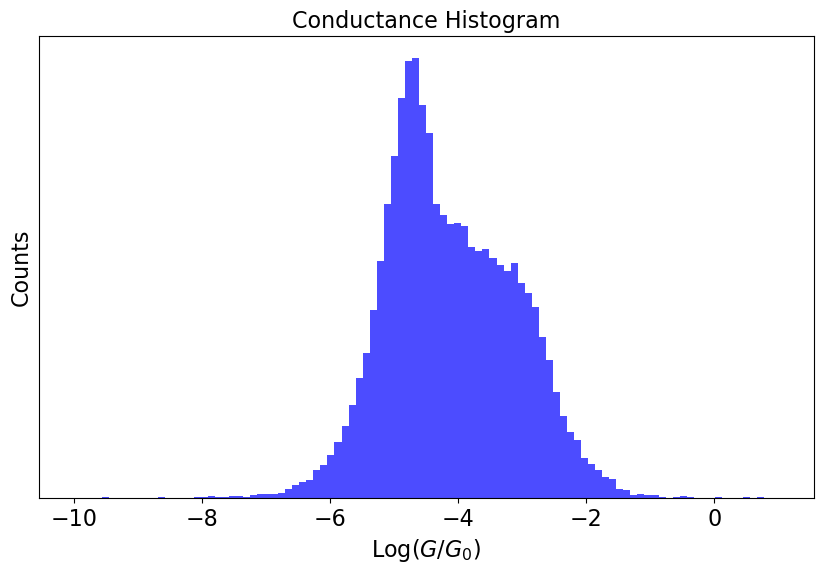

In [67]:
title = "Conductance Histogram"
plt.figure(figsize=(10, 6))
plt.hist(np.concatenate(data["Log(G/G0)"].values), 
         bins=100, 
         color="blue", 
         alpha=0.7, 
         range=(-10, 1), #change this to adjust the x-axis range of the histogram
         density=True)
if "Normalized" in file:
    plt.xlabel("Log($G/G_0$) per molecule")
else:
    plt.xlabel("Log($G/G_0$)")
plt.ylabel("Counts")
plt.yticks([])
plt.title(title)

save_plots(folder, title)

plt.show()

## Windowed Conductance histogram, with multiple mean and std ranges

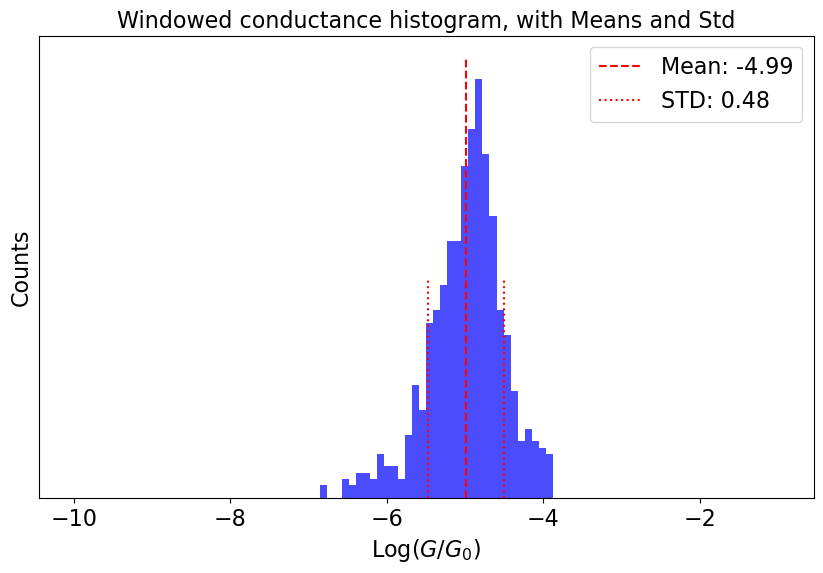

In [68]:
title = "Windowed conductance histogram, with Means and Std"

# Set the bias window for filtering the data
vmin = -0.05
vmax = 0.05

colours = ["red", "orange", "purple", "olive", "cyan"]

g = np.concatenate(data["Log(G/G0)"].values)
v = np.concatenate(data["Bias"].values)
gfiltered = np.array(g[(v>=vmin) & (v<=vmax)])
gfiltered = np.ma.masked_invalid(gfiltered)
#gfiltered = np.ma.masked_array(gfiltered, mask = gfiltered < -10) # you may want to adjust this threshold depending on the noise level in your data, or comment out to include all values

# Calculate the mean and standard deviation for the specified ranges
meanRanges = [(-10,-1)]
allMeanStd = []
for value in meanRanges:
    gwindow = np.array(gfiltered[(gfiltered>=value[0]) & (gfiltered<value[1])])
    meanStd = (np.nanmean(gwindow), np.nanstd(gwindow))
    allMeanStd.append(meanStd)

plt.figure(figsize=(10, 6))
plt.hist(gfiltered.compressed(), 
         bins=100, 
         color="blue", 
         alpha=0.7, 
         range=(-10,-1), #change this to adjust the x-axis range of the histogram
         density=True)
if "Normalized" in file:
    plt.xlabel("Log($G/G_0$) per molecule")
else:
    plt.xlabel("Log($G/G_0$)")
plt.ylabel("Counts")
plt.yticks([])
plt.title(title)
ymax = plt.ylim()[1]
for value in allMeanStd:
    gMean, gSTD = value
    plt.vlines(gMean, 0, ymax, colors=colours[allMeanStd.index(value)], linestyles='dashed', label=f'Mean: {gMean:.2f}')
    plt.vlines([gMean - gSTD, gMean + gSTD], 0, ymax*0.5, colors=colours[allMeanStd.index(value)], linestyles='dotted', label=f'STD: {gSTD:.2f}')
plt.legend()

save_plots(folder, title)

plt.show()


## Bias vs Current 2-D histogram

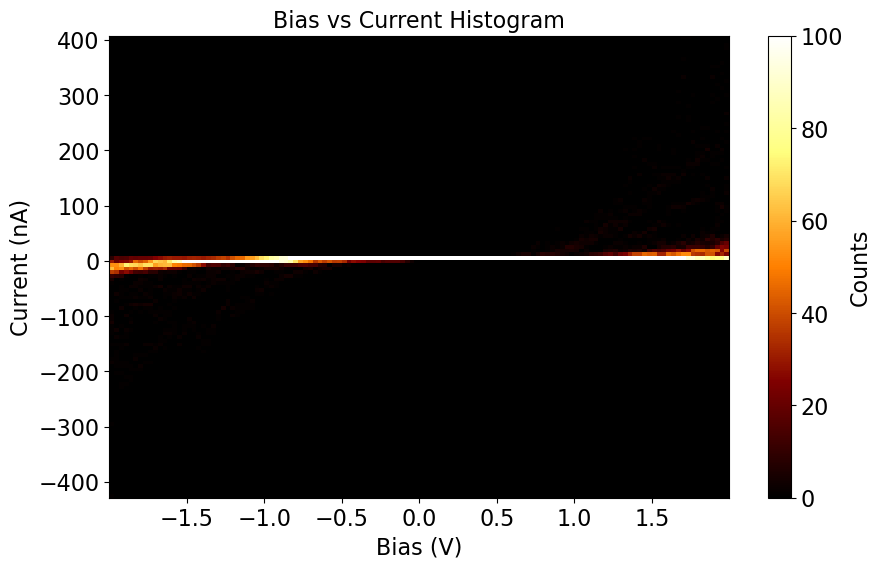

In [69]:
title = "Bias vs Current Histogram"
plt.figure(figsize=(10, 6))
plt.hist2d(np.concatenate(data["Bias"].values),
            np.concatenate(data["Current"].values),
            bins=(128,128), 
            cmap=plt.cm.afmhot, 
            #range=((-2,2),(-5000,5000)), #change range to adjust the x and y axis ranges or comment out for automatic scaling
            vmin = 0, vmax = 100) #change vmin and vmax to adjust the color scale range
plt.colorbar(label='Counts')
plt.xlabel("Bias (V)")
if "Normalized" in file:
    plt.ylabel("Current (nA) per molecule")
else:
    plt.ylabel("Current (nA)")
plt.title(title)

save_plots(folder, title)
    
plt.show()

## Bias vs Conductance 2-D histogram

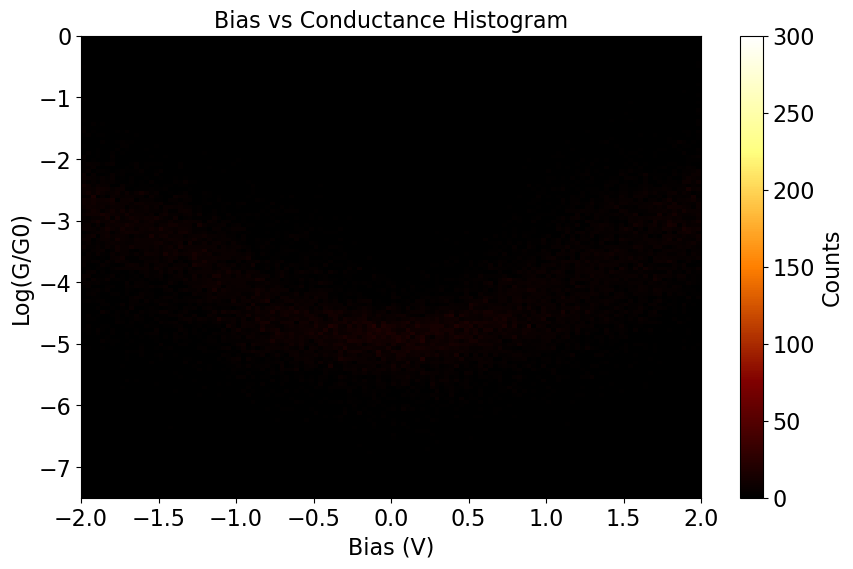

In [70]:
title = "Bias vs Conductance Histogram"
plt.figure(figsize=(10, 6))
plt.hist2d(np.concatenate(data["Bias"].values), 
           np.concatenate(data["Log(G/G0)"].values), 
           bins=(128,128), cmap=plt.cm.afmhot, 
           range=((-2,2),(-7.5,0)), #change range to adjust the x and y axis ranges or comment out for automatic scaling
           vmin = 0, vmax = 300) #change vmin and vmax to adjust the color scale range
plt.colorbar(label='Counts')
plt.xlabel("Bias (V)")
if "Normalized" in file:
    plt.ylabel("Log(G/G0) per molecule")
else:
    plt.ylabel("Log(G/G0)")
plt.title(title)

save_plots(folder, title)
    
plt.show()

## Out and back averages

remember to run the out and back splitting code first!

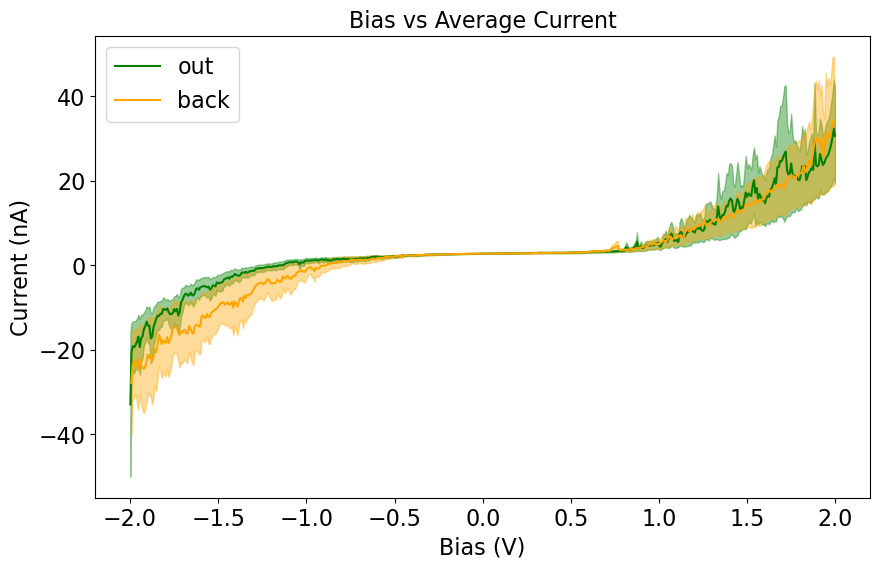

In [71]:
title = "Bias vs Average Current"

outCurrentPAvg = np.nanmean(np.array(outDataP["Current"].tolist()),axis=0)
outCurrentPSEM = stats.sem(np.array(outDataP["Current"].tolist()), axis=0, nan_policy='omit')
backCurrentPAvg = np.nanmean(np.array(backDataP["Current"].tolist()),axis=0)
backCurrentPSEM = stats.sem(np.array(backDataP["Current"].tolist()), axis=0, nan_policy='omit')
outCurrentNAvg = np.nanmean(np.array(outDataN["Current"].tolist()),axis=0)
outCurrentNSEM = stats.sem(np.array(outDataN["Current"].tolist()), axis=0, nan_policy='omit')
backCurrentNAvg = np.nanmean(np.array(backDataN["Current"].tolist()),axis=0)
backCurrentNSEM = stats.sem(np.array(backDataN["Current"].tolist()), axis=0, nan_policy='omit')

plt.figure(figsize=(10, 6))
plt.plot(outDataP["Bias"].iloc[0], outCurrentPAvg , label="out", color="green")
plt.fill_between(outDataP["Bias"].iloc[0], outCurrentPAvg - outCurrentPSEM, outCurrentPAvg + outCurrentPSEM, color="green", alpha=0.4)
plt.plot(backDataP["Bias"].iloc[0], backCurrentPAvg, label="back", color="orange")
plt.fill_between(backDataP["Bias"].iloc[0], backCurrentPAvg - backCurrentPSEM, backCurrentPAvg + backCurrentPSEM, color="orange", alpha=0.4)
plt.plot(outDataN["Bias"].iloc[0], outCurrentNAvg , color="green")
plt.fill_between(outDataN["Bias"].iloc[0], outCurrentNAvg - outCurrentNSEM, outCurrentNAvg + outCurrentNSEM, color="green", alpha=0.4)
plt.plot(backDataN["Bias"].iloc[0], backCurrentNAvg, color="orange")
plt.fill_between(backDataN["Bias"].iloc[0], backCurrentNAvg - backCurrentNSEM, backCurrentNAvg + backCurrentNSEM, color="orange", alpha=0.4)
plt.xlabel("Bias (V)")
if "Normalized" in file:
    plt.ylabel("Current (nA) per molecule")
else:
    plt.ylabel("Current (nA)")
plt.title(title)
plt.legend()

save_plots(folder, title)
    
plt.show()


## Out and back Log averages

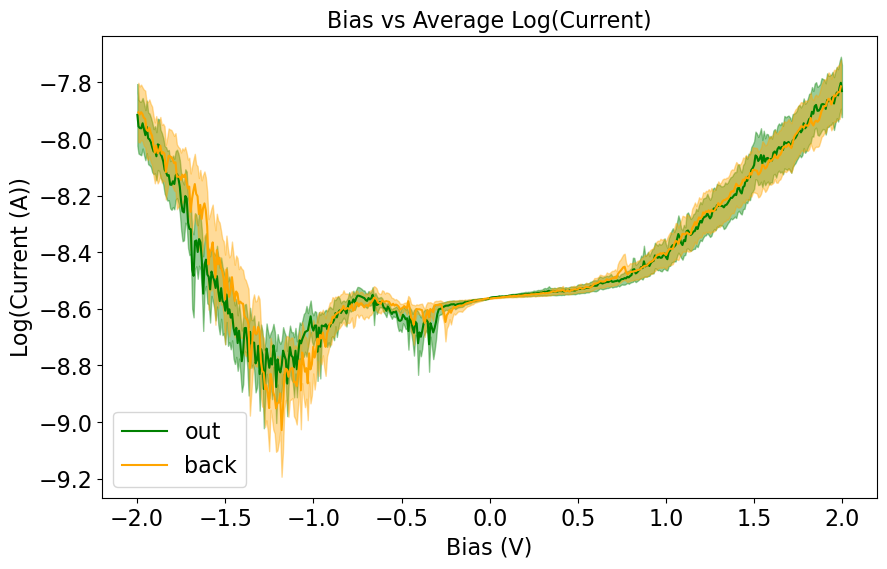

In [72]:
title = "Bias vs Average Log(Current)"

outCurrentPAvg = np.nanmean(np.array(outDataP["Log(Current)"].tolist()),axis=0)
outCurrentPSEM = stats.sem(np.array(outDataP["Log(Current)"].tolist()), axis=0, nan_policy='omit')
backCurrentPAvg = np.nanmean(np.array(backDataP["Log(Current)"].tolist()),axis=0)
backCurrentPSEM = stats.sem(np.array(backDataP["Log(Current)"].tolist()), axis=0, nan_policy='omit')
outCurrentNAvg = np.nanmean(np.array(outDataN["Log(Current)"].tolist()),axis=0)
outCurrentNSEM = stats.sem(np.array(outDataN["Log(Current)"].tolist()), axis=0, nan_policy='omit')
backCurrentNAvg = np.nanmean(np.array(backDataN["Log(Current)"].tolist()),axis=0)
backCurrentNSEM = stats.sem(np.array(backDataN["Log(Current)"].tolist()), axis=0, nan_policy='omit')

plt.figure(figsize=(10, 6))
plt.plot(outDataP["Bias"].iloc[0], outCurrentPAvg , label="out", color="green")
plt.fill_between(outDataP["Bias"].iloc[0], outCurrentPAvg - outCurrentPSEM, outCurrentPAvg + outCurrentPSEM, color="green", alpha=0.4)
plt.plot(backDataP["Bias"].iloc[0], backCurrentPAvg, label="back", color="orange")
plt.fill_between(backDataP["Bias"].iloc[0], backCurrentPAvg - backCurrentPSEM, backCurrentPAvg + backCurrentPSEM, color="orange", alpha=0.4)
plt.plot(outDataN["Bias"].iloc[0], outCurrentNAvg , color="green")
plt.fill_between(outDataN["Bias"].iloc[0], outCurrentNAvg - outCurrentNSEM, outCurrentNAvg + outCurrentNSEM, color="green", alpha=0.4)
plt.plot(backDataN["Bias"].iloc[0], backCurrentNAvg, color="orange")
plt.fill_between(backDataN["Bias"].iloc[0], backCurrentNAvg - backCurrentNSEM, backCurrentNAvg + backCurrentNSEM, color="orange", alpha=0.4)
plt.xlabel("Bias (V)")
if "Normalized" in file:
    plt.ylabel("Log(Current (A)) per molecule")
else:
    plt.ylabel("Log(Current (A))")
plt.title(title)
plt.legend()

save_plots(folder, title)
    
plt.show()

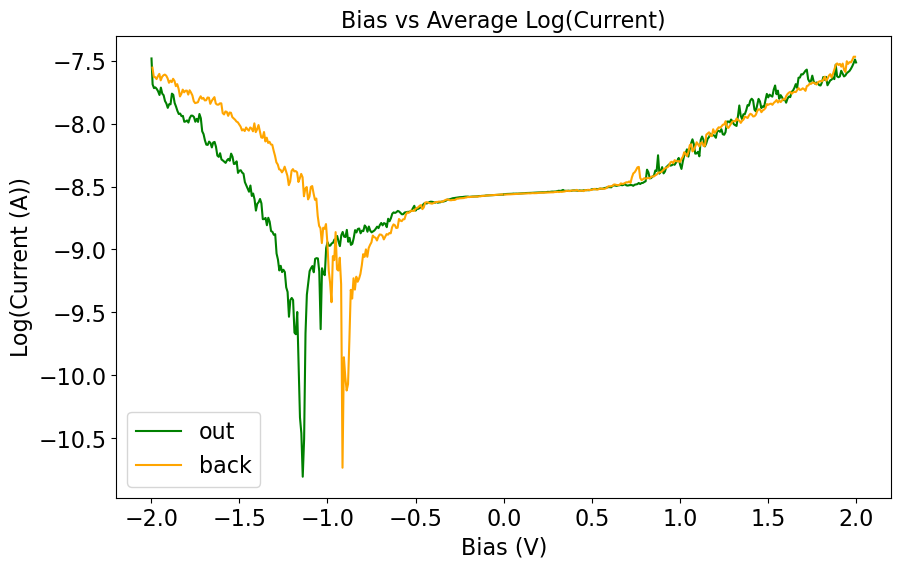

In [73]:
title = "Bias vs Average Log(Current)"

outCurrentPAvg = np.log10(np.abs(np.nanmean(np.array(outDataP["Current"].tolist())*1e-9,axis=0)))
outCurrentPSEM = np.log10(np.abs(stats.sem(np.array(outDataP["Current"].tolist())*1e-9, axis=0, nan_policy='omit')))
backCurrentPAvg = np.log10(np.abs(np.nanmean(np.array(backDataP["Current"].tolist())*1e-9,axis=0)))
backCurrentPSEM = np.log10(np.abs(stats.sem(np.array(backDataP["Current"].tolist())*1e-9, axis=0, nan_policy='omit')))
outCurrentNAvg = np.log10(np.abs(np.nanmean(np.array(outDataN["Current"].tolist())*1e-9,axis=0)))
outCurrentNSEM = np.log10(np.abs(stats.sem(np.array(outDataN["Current"].tolist())*1e-9, axis=0, nan_policy='omit')))
backCurrentNAvg = np.log10(np.abs(np.nanmean(np.array(backDataN["Current"].tolist())*1e-9,axis=0)))
backCurrentNSEM = np.log10(np.abs(stats.sem(np.array(backDataN["Current"].tolist())*1e-9, axis=0, nan_policy='omit')))

plt.figure(figsize=(10, 6))
plt.plot(outDataP["Bias"].iloc[0], outCurrentPAvg , label="out", color="green")
#plt.fill_between(outDataP["Bias"].iloc[0], outCurrentPAvg - outCurrentPSEM, outCurrentPAvg + outCurrentPSEM, color="green", alpha=0.4)
plt.plot(backDataP["Bias"].iloc[0], backCurrentPAvg, label="back", color="orange")
#plt.fill_between(backDataP["Bias"].iloc[0], backCurrentPAvg - backCurrentPSEM, backCurrentPAvg + backCurrentPSEM, color="orange", alpha=0.4)
plt.plot(outDataN["Bias"].iloc[0], outCurrentNAvg , color="green")
#plt.fill_between(outDataN["Bias"].iloc[0], outCurrentNAvg - outCurrentNSEM, outCurrentNAvg + outCurrentNSEM, color="green", alpha=0.4)
plt.plot(backDataN["Bias"].iloc[0], backCurrentNAvg, color="orange")
#plt.fill_between(backDataN["Bias"].iloc[0], backCurrentNAvg - backCurrentNSEM, backCurrentNAvg + backCurrentNSEM, color="orange", alpha=0.4)
plt.xlabel("Bias (V)")
if "Normalized" in file:
    plt.ylabel("Log(Current (A)) per molecule")
else:
    plt.ylabel("Log(Current (A))")
plt.title(title)
plt.legend()

#save_plots(folder, title)
    
plt.show()

## Out and back averages with histogram

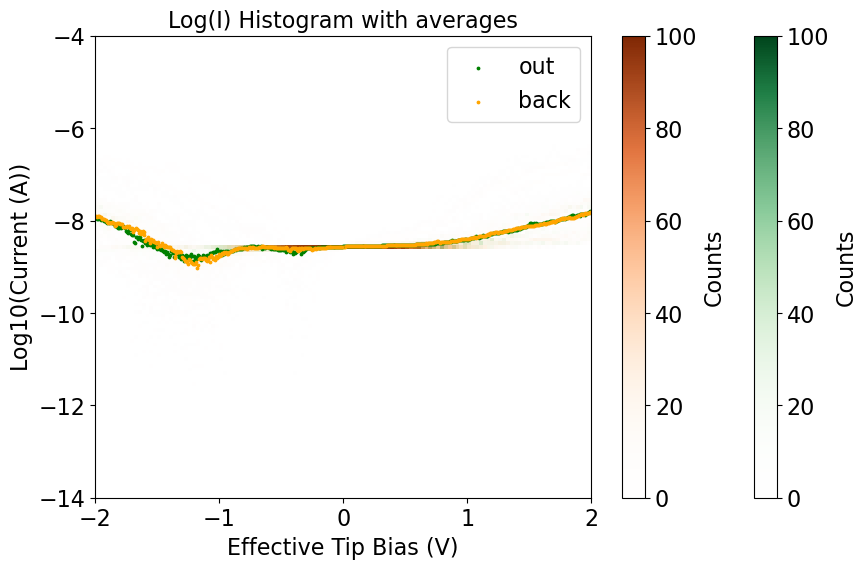

In [74]:
title = "Log(I) Histogram with averages"

outCurrentPAvg = np.nanmean(np.array(outDataP["Log(Current)"].tolist()),axis=0)
outCurrentPSEM = stats.sem(np.array(outDataP["Log(Current)"].tolist()), axis=0, nan_policy='omit')
backCurrentPAvg = np.nanmean(np.array(backDataP["Log(Current)"].tolist()),axis=0)
backCurrentPSEM = stats.sem(np.array(backDataP["Log(Current)"].tolist()), axis=0, nan_policy='omit')
outCurrentNAvg = np.nanmean(np.array(outDataN["Log(Current)"].tolist()),axis=0)
outCurrentNSEM = stats.sem(np.array(outDataN["Log(Current)"].tolist()), axis=0, nan_policy='omit')
backCurrentNAvg = np.nanmean(np.array(backDataN["Log(Current)"].tolist()),axis=0)
backCurrentNSEM = stats.sem(np.array(backDataN["Log(Current)"].tolist()), axis=0, nan_policy='omit')

plt.figure(figsize=(10, 6))
hist1 = plt.hist2d(np.concatenate(outDataP["Bias"].values), 
                   np.concatenate(outDataP["Log(Current)"].values), 
                   bins=(128,128), cmap=fading_green, 
                   range=((-2,2),(-14,-4)), #change range to adjust the x and y axis ranges or comment out for automatic scaling
                   vmin = 0, vmax = 100) #change vmin and vmax to adjust the color scale range
hist2 = plt.hist2d(np.concatenate(backDataP["Bias"].values), 
                   np.concatenate(backDataP["Log(Current)"].values),
                   bins=(128,128), cmap=fading_orange, 
                   range=((-2,2),(-14,-4)), #change range to adjust the x and y axis ranges or comment out for automatic scaling
                   vmin = 0, vmax = 100) #change vmin and vmax to adjust the color scale range
hist3 = plt.hist2d(np.concatenate(outDataN["Bias"].values),
                   np.concatenate(outDataN["Log(Current)"].values),
                   bins=(128,128), cmap=fading_green, 
                   range=((-2,2),(-14,-4)), #change range to adjust the x and y axis ranges or comment out for automatic scaling
                   vmin = 0, vmax = 100) #change vmin and vmax to adjust the color scale range
hist4 = plt.hist2d(np.concatenate(backDataN["Bias"].values),
                   np.concatenate(backDataN["Log(Current)"].values),
                   bins=(128,128), cmap=fading_orange, 
                   range=((-2,2),(-14,-4)), #change range to adjust the x and y axis ranges or comment out for automatic scaling
                   vmin = 0, vmax = 100) #change vmin and vmax to adjust the color scale range
plt.colorbar(hist1[3], label="Counts", orientation="vertical")
plt.colorbar(hist4[3], label="Counts", orientation="vertical")

plt.scatter(outDataP["Bias"].iloc[0], outCurrentPAvg, label="out", color="green", s=3)
plt.scatter(backDataP["Bias"].iloc[0], backCurrentPAvg, label="back", color="orange", s=3)
plt.scatter(outDataN["Bias"].iloc[0], outCurrentNAvg, color="green", s=3)
plt.scatter(backDataN["Bias"].iloc[0], backCurrentNAvg, color="orange", s=3)

plt.xlabel("Effective Tip Bias (V)")
if "Normalized" in file:
    plt.ylabel("Log10(Current (A)) per molecule")
else:
    plt.ylabel("Log10(Current (A))")
plt.title(title)
plt.legend()
save_plots(folder, title)
plt.show()